# Seattle Public Library Physical vs Digital Checkouts

This notebook answers: **How have Seattle Public Library physical vs digital checkout totals changed across complete years, and which recent complete year shows the largest digital share?**

Dataset reference used first: `seattle-public-library/README.md`.

The README says `combined_checkout_totals_by_month_usageclass.csv` has one row for one `usageclass` in one month of one year. That means this notebook aggregates monthly totals into annual totals, after checking that a year has all 12 months for both physical and digital usage classes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

project_root = Path.cwd()
while not (project_root / "seattle-public-library").exists():
    if project_root.parent == project_root:
        raise FileNotFoundError("Could not find project root with seattle-public-library directory.")
    project_root = project_root.parent

data_path = project_root / "seattle-public-library" / "combined_checkout_totals_by_month_usageclass.csv"
asset_dir = project_root / "agent-format-experiment" / "notebook-agent" / "reports" / "assets"
asset_dir.mkdir(parents=True, exist_ok=True)

checkout_totals = pd.read_csv(data_path)
checkout_totals["usageclass"] = checkout_totals["usageclass"].str.lower()

print(f"Rows: {len(checkout_totals):,}")
print(f"Columns: {list(checkout_totals.columns)}")
display(checkout_totals.head())

Rows: 501
Columns: ['checkout_year', 'checkout_month', 'usageclass', 'total_checkouts', 'month_total_checkouts', 'usageclass_share', 'title_month_rows', 'sample_rows']


,checkout_year,checkout_month,usageclass,total_checkouts,month_total_checkouts,usageclass_share,title_month_rows,sample_rows
0,2005,4,physical,252663,252663,1.0,117681,0
1,2005,5,physical,401395,401395,1.0,148224,0
2,2005,6,physical,502439,502439,1.0,160575,0
3,2005,7,physical,343668,343668,1.0,132711,0
4,2005,8,physical,373707,373707,1.0,137500,0


## Row Meaning and Scope

Each row is already a grouped monthly total for one usage class. Before plotting annual trends, we verify that the file contains the expected usage classes and inspect the year range represented in the monthly totals.

In [2]:
usageclass_values = checkout_totals["usageclass"].drop_duplicates().sort_values()
year_minimum = checkout_totals["checkout_year"].min()
year_maximum = checkout_totals["checkout_year"].max()

rows_by_usageclass = checkout_totals["usageclass"].value_counts().sort_index()

print(f"Year range in monthly totals: {year_minimum} to {year_maximum}")
print("Usage classes present:")
display(usageclass_values.to_frame(name="usageclass"))
print("Rows by usage class:")
display(rows_by_usageclass.to_frame(name="row_count"))

Year range in monthly totals: 2005 to 2026
Usage classes present:


,usageclass
5,digital
0,physical


Rows by usage class:


,row_count
usageclass,
digital,248
physical,253


In [3]:
analysis_rows = checkout_totals[checkout_totals["usageclass"].isin(["digital", "physical"])].copy()

monthly_counts = (
    analysis_rows
    .groupby(["checkout_year", "usageclass"])["checkout_month"]
    .nunique()
    .reset_index(name="month_count")
)

month_counts_wide = monthly_counts.pivot(
    index="checkout_year",
    columns="usageclass",
    values="month_count",
).fillna(0)

month_counts_wide = month_counts_wide.rename(
    columns={
        "digital": "digital_months",
        "physical": "physical_months",
    }
)

complete_year_mask = (
    (month_counts_wide["digital_months"] == 12)
    & (month_counts_wide["physical_months"] == 12)
)

complete_years = month_counts_wide.loc[complete_year_mask].index.tolist()

print(f"Complete years with 12 digital months and 12 physical months: {len(complete_years)}")
display(month_counts_wide.tail(8))
print(f"First complete year: {min(complete_years)}")
print(f"Last complete year: {max(complete_years)}")

Complete years with 12 digital months and 12 physical months: 20


usageclass,digital_months,physical_months
checkout_year,,
2019,12,12
2020,12,12
2021,12,12
2022,12,12
2023,12,12
2024,12,12
2025,12,12
2026,4,4


First complete year: 2006
Last complete year: 2025


In [4]:
complete_year_rows = analysis_rows[analysis_rows["checkout_year"].isin(complete_years)].copy()

annual_totals_long = (
    complete_year_rows
    .groupby(["checkout_year", "usageclass"])["total_checkouts"]
    .sum()
    .reset_index()
)

annual_totals = annual_totals_long.pivot(
    index="checkout_year",
    columns="usageclass",
    values="total_checkouts",
).reset_index()

annual_totals["total_checkouts"] = annual_totals["digital"] + annual_totals["physical"]
annual_totals["digital_share"] = annual_totals["digital"] / annual_totals["total_checkouts"]
annual_totals["physical_share"] = annual_totals["physical"] / annual_totals["total_checkouts"]
annual_totals["digital_change_since_previous_year"] = annual_totals["digital"].diff()
annual_totals["physical_change_since_previous_year"] = annual_totals["physical"].diff()

summary_path = asset_dir / "annual_checkout_summary.csv"
annual_totals.to_csv(summary_path, index=False)

display_columns = [
    "checkout_year",
    "physical",
    "digital",
    "total_checkouts",
    "digital_share",
    "physical_share",
]

print(f"Saved annual summary table to: {summary_path.relative_to(project_root)}")
display(annual_totals[display_columns].tail(10))

Saved annual summary table to: agent-format-experiment/notebook-agent/reports/assets/annual_checkout_summary.csv


usageclass,checkout_year,physical,digital,total_checkouts,digital_share,physical_share
10,2016,6568318,2452733,9021051,0.271890,0.728110
11,2017,6479434,2752214,9231648,0.298128,0.701872
12,2018,6102655,3046521,9149176,0.332983,0.667017
13,2019,5768324,3430759,9199083,0.372946,0.627054
14,2020,1743701,4310016,6053717,0.711962,0.288038
15,2021,2966650,4394381,7361031,0.596979,0.403021
16,2022,3710181,4692195,8402376,0.558437,0.441563
17,2023,3720574,5476658,9197232,0.595468,0.404532
18,2024,2954034,5366644,8320678,0.644977,0.355023
19,2025,3436853,6076196,9513049,0.638722,0.361278


In [5]:
recent_year_count = 5
recent_complete_years = annual_totals.tail(recent_year_count).copy()
largest_recent_digital_share = recent_complete_years.loc[
    recent_complete_years["digital_share"].idxmax()
].copy()

print(f"Recent complete years checked: {recent_complete_years['checkout_year'].tolist()}")
print(
    "Largest recent digital share: "
    f"{int(largest_recent_digital_share['checkout_year'])} "
    f"({largest_recent_digital_share['digital_share']:.1%})"
)

display(recent_complete_years[display_columns])

Recent complete years checked: [2021, 2022, 2023, 2024, 2025]
Largest recent digital share: 2024 (64.5%)


usageclass,checkout_year,physical,digital,total_checkouts,digital_share,physical_share
15,2021,2966650,4394381,7361031,0.596979,0.403021
16,2022,3710181,4692195,8402376,0.558437,0.441563
17,2023,3720574,5476658,9197232,0.595468,0.404532
18,2024,2954034,5366644,8320678,0.644977,0.355023
19,2025,3436853,6076196,9513049,0.638722,0.361278


Saved chart to: agent-format-experiment/notebook-agent/reports/assets/checkout_totals_by_usageclass_complete_years.svg


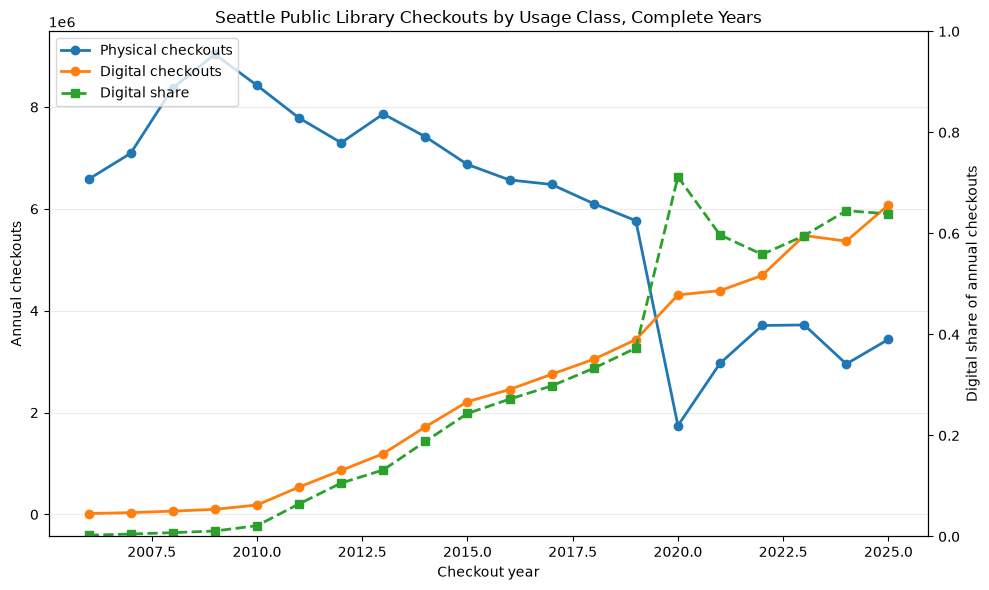

In [6]:
fig, first_axis = plt.subplots(figsize=(10, 6))

first_axis.plot(
    annual_totals["checkout_year"],
    annual_totals["physical"],
    marker="o",
    linewidth=2,
    label="Physical checkouts",
    color="#1f77b4",
)
first_axis.plot(
    annual_totals["checkout_year"],
    annual_totals["digital"],
    marker="o",
    linewidth=2,
    label="Digital checkouts",
    color="#ff7f0e",
)
first_axis.set_title("Seattle Public Library Checkouts by Usage Class, Complete Years")
first_axis.set_xlabel("Checkout year")
first_axis.set_ylabel("Annual checkouts")
first_axis.grid(True, axis="y", alpha=0.25)

second_axis = first_axis.twinx()
second_axis.plot(
    annual_totals["checkout_year"],
    annual_totals["digital_share"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Digital share",
    color="#2ca02c",
)
second_axis.set_ylabel("Digital share of annual checkouts")
second_axis.set_ylim(0, 1)

first_handles, first_labels = first_axis.get_legend_handles_labels()
second_handles, second_labels = second_axis.get_legend_handles_labels()
first_axis.legend(
    first_handles + second_handles,
    first_labels + second_labels,
    loc="upper left",
)

fig.tight_layout()
chart_path = asset_dir / "checkout_totals_by_usageclass_complete_years.svg"
fig.savefig(chart_path, format="svg")

print(f"Saved chart to: {chart_path.relative_to(project_root)}")
plt.show()